In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("ecommerce_dataset.csv")
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code,Latitude,Longtitude
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0,1.0,0.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0,1.0,0.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0,1.0,0.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0,1.0,0.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0,1.0,0.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0,1.0,0.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0,1.0,0.0


# Check types of data

In [4]:
df.dtypes

order_id                 int64
product                 object
category                object
price                  float64
quantity                 int64
payment_method          object
date                    object
total                  float64
Month                   object
Discount               float64
City Code              float64
Order Priority Code    float64
Latitude               float64
Longtitude             float64
dtype: object

# Drop irrelevant columns (Latitude, Longitude)

In [5]:
df = df.drop(["Latitude", "Longtitude"], axis=1)
df

,order_id,product,category,price,quantity,payment_method,date,total,Month,Discount,City Code,Order Priority Code
0,1,Watch,Electronics,12652.30,4,Easypaisa,01/01/2023,50609.20,January,0.0,1.0,2.0
1,2,Bag,Fashion,20053.64,2,Credit Card,02/01/2023,40107.28,January,0.1,1.0,2.0
2,3,Shoes,Fashion,13274.17,2,JazzCash,03/01/2023,26548.34,January,0.1,1.0,2.0
3,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
4,5,Bag,Accessories,23165.07,1,Debit Card,05/01/2023,23165.07,January,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
501,4,Bag,Electronics,15332.08,1,COD,04/01/2023,15332.08,January,0.1,1.0,2.0
502,18,Headphones,Electronics,14085.56,2,Debit Card,18/01/2023,28171.12,January,0.0,1.0,2.0
503,19,Laptop,Accessories,53657.14,4,Debit Card,19/01/2023,214628.56,January,0.1,1.0,2.0
504,20,Watch,Fashion,74385.39,4,Credit Card,20/01/2023,297541.56,January,0.0,1.0,2.0


# Rename columns City Code to City & Order Priority Code to Order Priority

In [6]:
df.rename(columns={
    "City Code": "City",
    "Order Priority Code": "Order Priority"
},inplace = True)
df.columns

Index(['order_id', 'product', 'category', 'price', 'quantity',
       'payment_method', 'date', 'total', 'Month', 'Discount', 'City',
       'Order Priority'],
      dtype='object')

# Check duplicate rows

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6


# Drop duplicate records

In [8]:
df = df.drop_duplicates()

# Check missing and null values

In [9]:
print(df.isnull().sum())

order_id           0
product            0
category           0
price              0
quantity           0
payment_method     0
date               0
total              0
Month              0
Discount           0
City              15
Order Priority    19
dtype: int64


# Fill missing sales value by their median

In [12]:
median_total = df["total"].median()
df["total"] = df["total"].fillna("medain_total")

# Exploratory Data Analysis (Key Observations)
### 1) Top 5 Best Selling Products
### a) Write Observation
### b) (Bar Chart) Using Seaborn

In [25]:
top_products = df.groupby("product")["quantity"].sum().sort_values(ascending=False).head(5)
top_products

product
Watch         256
Mobile        230
Headphones    227
Bag           189
Shoes         188
Name: quantity, dtype: int64

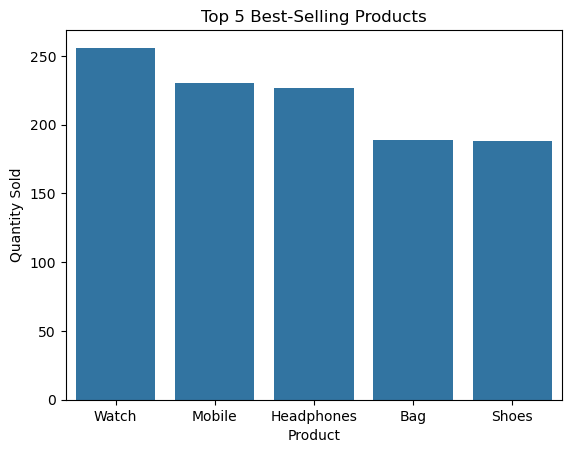

In [26]:
sns.barplot(x=top_products.index, y=top_products.values)

plt.title("Top 5 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

Observation: Watch is the best-selling product with a total quantity of 256 units, followed by Mobile with 230 units and Headphones with 227 units. Bag and Shoes have the lowest quantities among the top 5 products, with 189 and 188 units respectively. This shows that Watch is the most popular product based on quantity sold.

## 2) Payment Method Distribution
### a) Write Observation
### b) (Pie Chart) Using Matplotlib

In [29]:
payment_methods = df["payment_method"].value_counts()
payment_methods

payment_method
JazzCash       112
Credit Card    107
Easypaisa      105
COD             97
Debit Card      79
Name: count, dtype: int64

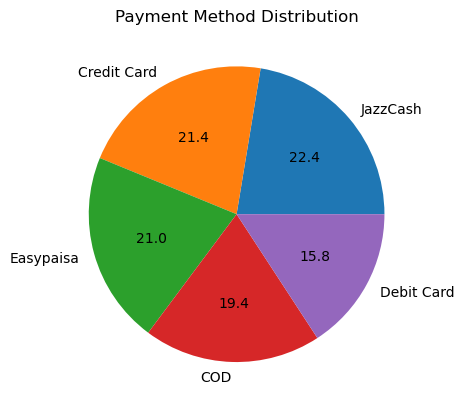

In [36]:
plt.pie(payment_methods.values, labels=payment_methods.index, autopct='%1.1f')

plt.title("Payment Method Distribution")

plt.show()

Observation: JazzCash is the most commonly used payment method with 112 orders, followed by Credit Card with 107 orders and Easypaisa with 105 orders. Debit Card is the least used payment method with 79 orders. Overall, the distribution is fairly balanced, but JazzCash is slightly more popular among customers.

## 3) Month-wise Sales
### a) Write Observation
### b) (Line Chart) Using Matplotlib

In [39]:
month_sales = df.groupby("Month")["total"].sum()
month_sales

Month
April        6275753.74
August       2557288.54
December     3952563.75
February     5545040.22
January      6238414.59
July         2688475.62
June         2860920.11
March        6711119.66
May          5909845.92
November     2805153.37
October      3139444.82
September    2515916.08
Name: total, dtype: float64

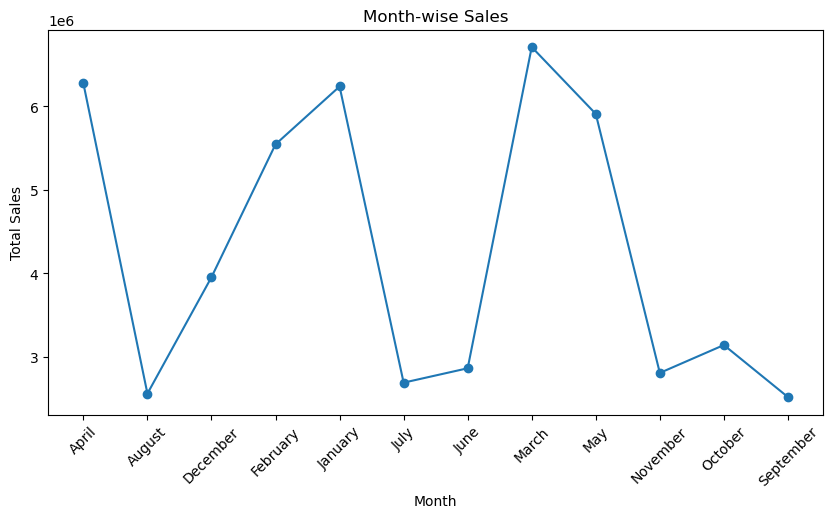

In [42]:
plt.figure(figsize=(10,5))
plt.plot(
    month_sales.index,
    month_sales.values,
    marker="o"
)

plt.title("Month-wise Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

Sales fluctuate across the months. March recorded the highest sales, while September recorded the lowest sales. Sales were also relatively high in April, January, and May, whereas August, July, June, November, and September had lower sales. Overall, the monthly sales show a fluctuating trend.

## 4) Show City wise sales
### a) Replace City Names 
### b) Horizontal Bar Chart using Seaborn
### c) Write Observation

In [45]:
city_names = {
    1: "Karachi",
    2: "Lahore",
    3: "Islamabad",
    4: "Faisalabad",
    5: "Quetta",
    6: "Peshawar"
}

df["City"] = df["City"].replace(city_names)
df["City"]

0         Karachi
1         Karachi
2         Karachi
3         Karachi
4         Karachi
          ...    
495    Faisalabad
496    Faisalabad
497    Faisalabad
498    Faisalabad
499    Faisalabad
Name: City, Length: 500, dtype: object

In [46]:
city_sales = df.groupby("City")["total"].sum()
print(city_sales)

City
Faisalabad     6318998.97
Islamabad      8028811.58
Karachi        5060916.14
Lahore        14665005.16
Peshawar       6194016.19
Quetta         9488620.43
Name: total, dtype: float64


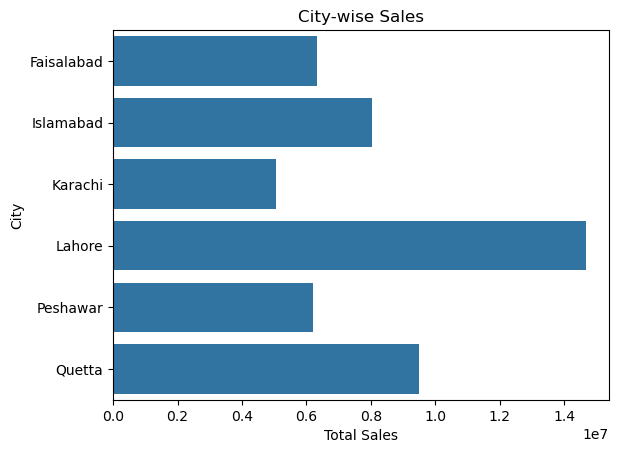

In [47]:
sns.barplot(x=city_sales.values, y=city_sales.index)

plt.title("City-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")

plt.show()

Lahore has the highest total sales, with approximately 14.67 million. Quetta has the second-highest sales, with approximately 9.49 million, while Islamabad has about 8.03 million. Faisalabad and Peshawar have similar sales of around 6.32 million and 6.19 million respectively. Karachi has the lowest total sales, with approximately 5.07 million. Overall, Lahore is the best-performing city in terms of total sales.

## 5) Show monthly Sales by Category 
### a) Side by side bar chart using matplotlib
### b) Write Observation

In [54]:
monthly_category_sales = df.groupby(["Month", "category"])["total"].sum().unstack()

print(monthly_category_sales)

category   Accessories  Electronics     Fashion
Month                                          
April       2387980.38   2265079.20  1622694.16
August       521529.94    881950.11  1153808.49
December    1005459.07   1460885.05  1486219.63
February    1178881.69   1929360.80  2436797.73
January     2745729.82   1855039.15  1637645.62
July         961408.72   1218489.97   508576.93
June        1421673.13    657353.10   781893.88
March       2749630.71   2457415.74  1504073.21
May         1240740.21   2352232.89  2316872.82
November     739060.88    991960.56  1074131.93
October      496080.70   1911295.72   732068.40
September    849152.91    952931.97   713831.20


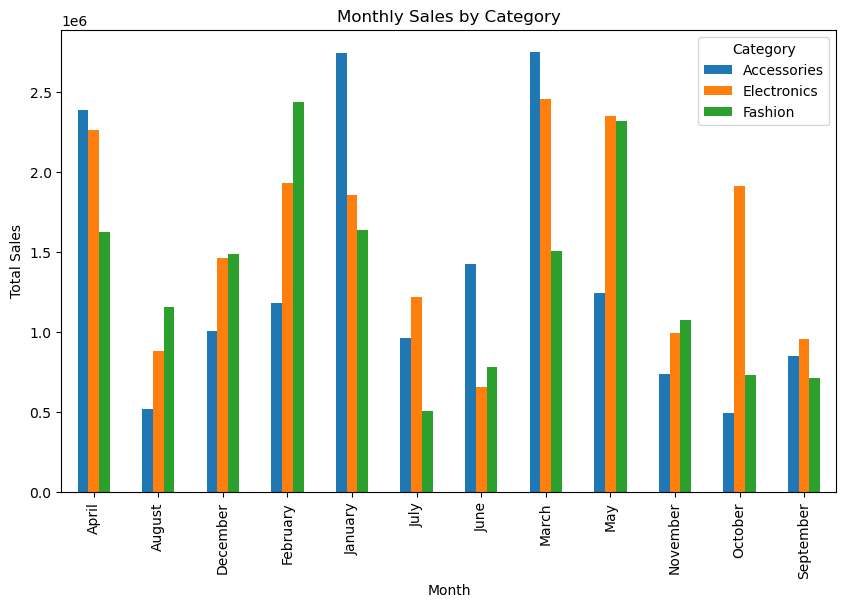

In [52]:
monthly_category_sales.plot(kind="bar", figsize=(10, 6))

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Category")

plt.show()

Sales vary across the months for all three categories. Accessories recorded its highest sales in March, at approximately 2.75 million. Electronics also had its highest sales in March, at approximately 2.46 million. Fashion recorded its highest sales in February, at approximately 2.44 million. Overall, Accessories performed strongly in several months, while Fashion had the lowest sales in September.